# Simulation of the waveguide modes

## Step 0: Open the Lumerical MODE session

In [1]:
%load_ext autoreload
%autoreload 2
# Remember to remove the lines after
import lumapi
from collections import OrderedDict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Find the current working directory and set the starting point for the base path

import lumapi_util as lu


# Open the session and build the first geometry (edit the build_geometry.lsf script)
sim = lumapi.MODE()


def lin2db(x):
    return 10 * np.log10(abs(x)) 


## Step 1: Create the geometry

Define the geometry function and set the default parameters.
> Edit this script to customize the geometry


In [19]:

from functools import partial
from dataclasses import dataclass

sim.switchtolayout()
sim.deleteall()

from lumapi_util.paths import STACK_DATA_DIR

stack_file = STACK_DATA_DIR / "sample_soi.lbr"
stack_length = 10

lu.add_layerstack_fromfile(sim, filename=stack_file.as_posix(), size=[stack_length, 20, None])


# Define the parameters
default_params = {
    "sidewall_angle": 90,
    "wavelength": 1.55,
    "enable_substrate": False
}


@dataclass
class Section:
    layer: str
    w: float
    s: float = 0
    t: float = None

    def to_dict(self):
        return {
            f"t_{self.layer}": self.t,
            f"w_{self.layer}": self.w,
            f"s_{self.layer}": self.s
        }


# Define waveguide layers and corresponding parameter keys
def waveguide_section(width, offset):
    return [lu.straight_waveguide(10, width, (-5, offset))] if width else []

# Define your stack flexibly
sections = [
    Section("WG", w=0.4),
]


# Add section params into default_params
for sec in sections:
    default_params.update(sec.to_dict())




# Create a mod geometry specific for the problem
def mod_geometry(sim, sections=sections, **params):
    params = {**default_params, **params}
    sim.switchtolayout()

    enable_substrate = params.get('enable_substrate', False)
    wl = params.get("wavelength", 1.55)
    
    # Loop over all defined sections
    for sec in sections:
        w = params.get(f"w_{sec.layer}", 0.0)
        s = params.get(f"s_{sec.layer}", 0.0)
        t = params.get(f"t_{sec.layer}")
        if t is not None:
            sim.select("layer group")
            sim.setlayer(sec.layer, "thickness", t * 1e-6)
        vtx = waveguide_section(w, s)
        lu.set_geometries_to_layer(sim, vtx, sec.layer)


    # Reset the FDE
    lu.define_fde(sim, size=[None, 6., 5.], center=[0., 0., 0.11], wavelength=params["wavelength"], bc=["PML"] * 4)
    
        
    # Add meshing
    lu.define_mesh(sim, name="mesh_struct", size=[stack_length, 1, 0.3], center=[0, 0., 0.11], steps=[None, 0.02, 0.02])
    if enable_substrate:
        lu.define_mesh(sim, name="mesh_sub_interface", size=[stack_length, 50., 0.2], center=[stack_length/2, 0., -2.6], steps=[None, None, 0.02])  # Add a mesh to the interface
        lu.define_mesh(sim, name="mesh_sub", size=[stack_length, 50., 50], center=[stack_length/2, 0., -2.6 - 25], steps=[None, wl / 15, wl / 15])
    



# Example
mod_geometry(sim, w_WG=0.4, wavelength=1.55)

[ensure_object] 'FDE' not found. Creating a new 'FDE'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...


## Step 2: Run the FDE simulation to find the modes

---

### **Problem: Eigenmodes in Optical Waveguides**

We want to find the **guided modes** (eigenmodes) supported by an optical waveguide, starting from Maxwell's equations under specific assumptions.



### **1. Starting Point: Helmholtz Equation**

From Maxwell’s equations (time-harmonic fields with $e^{-i\omega t}$):

$$
\nabla^2 \mathbf{E} + k_0^2 n^2(x, y) \mathbf{E} = 0
$$

where:

* $\mathbf{E}$: electric field,
* $k_0 = \frac{\omega}{c}$: vacuum wave number,
* $n(x, y)$: refractive index profile (assumed invariant along $z$).



### **2. Assumptions**

* **Linear, isotropic, non-magnetic, lossless** dielectric.
* **Translational invariance** along propagation axis $z$.
* Solve for **monochromatic fields**: $\mathbf{E}(x, y, z) = \mathbf{e}(x, y) e^{-i\beta z}$
* Weakly guiding: $n(x, y) \approx \text{const.} \Rightarrow$ scalar approximation often used.



### **3. Scalar and Vectorial Wave Equation**

Assume a scalar field $\psi(x, y, z) = \psi(x, y) e^{-i\beta z}$:

$$
\nabla_T^2 \psi(x, y) + \left[ k_0^2 n^2(x, y) - \beta^2 \right] \psi(x, y) = 0
$$

where $\nabla_T^2 = \frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}$ is the **transverse Laplacian**. 
This is an **eigenvalue problem** for $\beta$ (the propagation constant).

For full-vectorial analysis, solve:

$$
\nabla_T \times \left( \nabla_T \times \mathbf{e}_T \right) + \left( k_0^2 n^2 - \beta^2 \right) \mathbf{e}_T = 0
$$

Where $\mathbf{e}_T$ is the transverse electric field. This yields **TE**, **TM**, or hybrid modes.


### **4. Boundary Conditions**

At material interfaces:

* Continuity of $\psi$ and its normal derivative.
* Solutions must be **bounded** (no energy at infinity for guided modes).
* In most cases, problems can be solved using **Perfectly Matched Layer** (PML) or **Perfect Electric Conductor** (PEC, known as Metal in Lumerical)
* PEC corresponds to the *Dirichlet* condition for the electric field, whereas the **Perfect Magnetic Conductor** (PMC) corresponds to the *Neumann* condition for the electric field.
* In presence of symmetries, you can use also **Symmetric** or **Anti-Symmetric** boundary conditions


| Condition Type  | Equation                                                                             | Physical Meaning                        |
| --------------- | ------------------------------------------------------------------------------------ | --------------------------------------- |
| PML             | $\nabla \cdot \left( \frac{1}{s} \nabla \psi \right) + k_0^2 n^2 \psi = 0$           | Absorbing boundary                      |
| PEC             | $\psi = 0$  (Dirichlet)                                                              | Electric field zero at metal            |
| PMC             | $\frac{\partial \psi}{\partial n} = 0$    (Neumann)                                  | No electric flux normal                 |
| Symmetric       | $\psi(x) = \psi(-x)$ (assuming symmetry plane $x_s=0$)                               | Even mode                               |
| Antisymmetric   | $\psi(x) = -\psi(-x)$ (assuming symmetry plane $x_s=0$)                              | Odd mode                                |
| Bloch           | $\psi(\mathbf{r} + \mathbf{a}) = \psi(\mathbf{r}) e^{i \mathbf{k} \cdot \mathbf{a}}$ | Periodic media, photonic crystals       |




### **5. Effective Index**

Modes exist only for $k_0 n_{\text{clad}} < \beta < k_0 n_{\text{core}}$. Define:

$$
n_{\text{eff}} = \frac{\beta}{k_0}
$$

Each eigenmode has a **field profile** $\psi(x, y)$ and a **propagation constant** $\beta$, or equivalently an **effective index** $n_{\text{eff}}$.







### **6. Output**

#### **Eigenmodes**: $\psi_m(x, y)$, each with **propagation constant** $\beta_m$

* Each **eigenvalue** $\beta_m$ corresponds to a **mode** $\psi_m(x, y)$.
* These are **discrete** values due to boundary conditions and index confinement.
* The number of guided modes depends on **wavelength**, **geometry**, and **index contrast**.
* **Bounds**: $n_{\text{clad}} < n_{\text{eff}, m} < n_{\text{core}}$
* **Higher-order modes** have:

  * **Lower** $\beta_m$
  * **Weaker confinement**





> ### Mode Tracking
> 
> As parameter $p$ changes (e.g., waveguide width), we want to **track a specific mode** $\psi(p)$, ensuring continuity of:
> 
> * Eigenvalue $\beta(p)$
> * Eigenfunction $\psi(p)$
> 
> We define a **tracking criterion** based on **mode overlap** between adjacent values of $p$:
> 
> $$
> \boxed{
> \text{Overlap} = \left| \left\langle \psi^{(p)}, \psi^{(p + \Delta p)} \right\rangle \right| = \left| \int \psi^{(p)}(x, y)^* \psi^{(p+\Delta p)}(x, y) \, dxdy \right|
> }
> $$
> 
> We assign to each mode at $p + \Delta p$ the label of the one at $p$ that **maximizes the overlap**.
> #### **Algorithm**
> 
> 1. At initial $p_0$, solve the eigenvalue problem (findmodes in Lumerical)
> 
> 2. Save the eigenmodes $\{\psi_i(p_0)\}$ (save the D-Card in Lumerical of all modes)
> 
> 3. Increment parameter: $p_1 = p_0 + \Delta p$
> 
> 4. Solve eigenproblem again and find $\{\psi_i(p_1)\}$
> 
> 5. For each $i$, compute: $O_{ij} = \left| \int \psi_i^*(p_0) \psi_j(p_1) \, dxdy \right|$ (run bestoverlap on each mode)
> 
> 6. Assign $\psi_j(p_1) \leftrightarrow \psi_i(p_0)$ using maximum $O_{ij}$
> 
> 7. Repeat.


In [13]:
import re

def find_neff(sim, n_modes=5, mode_tracking=True):
    # Be careful that the D-Cards are properly cleared before starting
    # Set the number of modes and find the modes, prepare the result
    sim.switchtolayout()
    sim.setnamed("FDE", "number of trial modes", n_modes)
    sim.findmodes()
    n_found = int(sim.nummodes())
    neffs =  np.full(n_modes, np.nan)

    if mode_tracking:
        mapping = {}
        for n in range(n_found):
            try:
                mapping[f"test_mode{n + 1}"] = sim.bestoverlap(f"test_mode{n + 1}") # Result could be mode1, mode2...
            except Exception as e:
                continue
    
        for n, (test_mode, mode) in enumerate(mapping.items()):
            neffs[n] = np.abs(np.squeeze(sim.getdata(f"FDE::data::{mode}", "neff")))
            sim.cleardcard(test_mode)
            sim.copydcard(mode, test_mode)

        used_indices = {int(re.search(r'\d+', v).group()) for v in mapping.values()}
        rem_modes = [i + 1 for i in range(min(n_modes, n_found)) if i + 1 not in used_indices]

        for n, mode_nr in enumerate(rem_modes, len(mapping)):
            if n >= n_modes:
                break  # Prevent out-of-bounds
            neffs[n] = np.abs(np.squeeze(sim.getdata(f"FDE::data::mode{mode_nr}", "neff")))
            sim.copydcard(f"mode{mode_nr}", f"test_mode{n + 1}")


    else:  # Just save the results
        for n in range(min(n_modes, n_found)):
            neffs[n] = np.abs(np.squeeze(sim.getdata(f"FDE::data::mode{n+1}", "neff")))
            
    return neffs



def unpack_array_column(df, col='result', prefix="val"):
    """Unpack a column of numpy arrays into multiple columns."""
    arr = np.vstack(df[col].to_numpy())
    cols = [f"{prefix}_{i}" for i in range(arr.shape[1])]
    unpacked = pd.DataFrame(arr, columns=cols, index=df.index)
    return pd.concat([df.drop(columns=[col]), unpacked], axis=1)


def plot_neff(df, parameter):
    plot_df = df.copy().set_index(parameter)
    plot_df = plot_df.filter(like='mode_')
    plot_df.plot(ylabel='Effective index', grid=True)


def neff_parameter_sweep(sim, setup_fn, parameter, n_modes=10, plot=True, **kwargs):
    sim.cleardcard()
    neff = lu.run_sweep(sim,
                        sweep_params=parameter,
                        setup_fn=setup_fn,
                        result_fn=partial(lu.find_neff, n_modes=n_modes),
                        postprocess_fn=partial(unpack_array_column, prefix='mode'),
                        **kwargs
                        )
    if plot:
        plot_neff(neff, next(iter(parameter)))
    return neff

## Strip waveguide - Si 220 nm @ 1550 nm 

100%|██████████| 15/15 [04:54<00:00, 19.62s/it, w_WG=2.9]

✅ Sweep completed. Results saved to sweep_results.csv


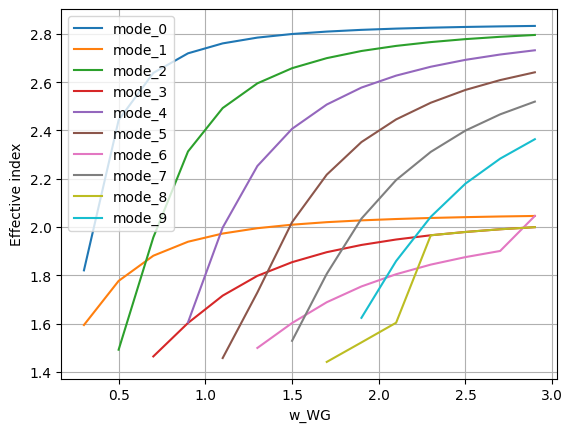

In [ ]:

df = neff_parameter_sweep(sim, 
                          setup_fn=partial(mod_geometry, wavelength=1.55), 
                          parameter={"w_WG": np.arange(0.1, 3, 0.2)},
                          n_modes=10,)

In [31]:
from scipy.interpolate import CubicSpline

def interp_sim_data(df: pd.DataFrame, columns, parameter=None, interp_function=CubicSpline):
    """
    Interpolates specified columns of a DataFrame using the given interpolation function.

    Parameters:
    ----------
    df : pd.DataFrame
        DataFrame containing the simulation data.
    columns : list or str
        Columns to interpolate.
    parameter : str or None
        The parameter to interpolate over. If None, uses the index.
    interp_function : callable
        A function/class from scipy.interpolate (e.g., CubicSpline, interp1d, etc.).

    Returns:
    --------
    dict
        A dictionary {column_name: interpolation_function}
    """
    if isinstance(columns, str):
        columns = [columns]

    x = df[parameter].values if parameter else df.index.values

    interpolators = {}
    for col in columns:
        y = df[col].values
        # Remove NaNs to avoid interpolation errors
        mask = ~pd.isna(x) & ~pd.isna(y)
        if mask.sum() < 2:
            raise ValueError(f"Not enough valid points to interpolate column '{col}'.")
        interpolators[col] = interp_function(x[mask], y[mask])

    return interpolators



neff_functions = interp_sim_data(neff, columns=["neff_1", "neff_2"])
neff1_fn = neff_functions["neff_1"]
neff2_fn = neff_functions["neff_2"]
display(neff1_fn(4))
display(neff2_fn(4))

array(1.70803861)

array(1.79273292)

## Study of abrupt interfaces mode overlap

Here we try to maximise the overlap integral between two different section. Criteria:
1. Overlap integral between the modes fields $\eta = \left| \left\langle \frac{E_1}{\|E_1\|}, \frac{E_2}{\|E_2\|} \right\rangle \right|^2$
2. Difference in effective indices $\left| n_{eff, in} - n_{eff, out} \right|$

> The inner product is defined as $\langle E_1, E_2 \rangle = \iint E_1^*(x, y) \cdot E_2(x, y) \, dx\,dy$